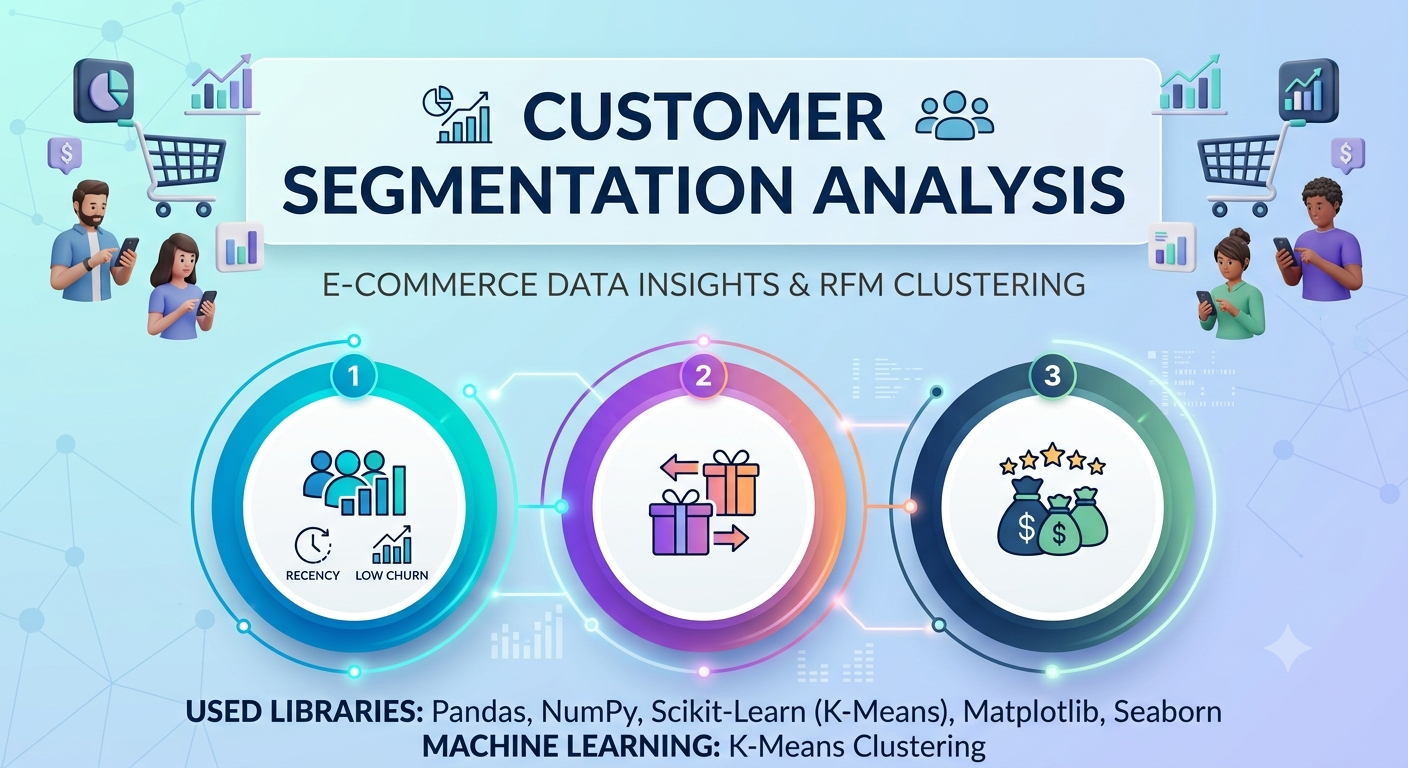

**Level 1 - Task 2:**
#  <b style="color: #8A2BE2;">#  Customer Segmentation Analysis</b>

<b style="color: #8A2BE2;">**Domain:**</b>Data Analytics

<b style="color: #8A2BE2;">**Internship:**</b>Oasis Infobyte (OIBSIP

**<b style="color: #8A2BE2;">Objective:</b>**

Apply clustering algorithms to segment an e-commerce company's customer base into distinct groups based on purchasing behaviour (RFM Analysis).


<b style="color: #8A2BE2;">**Import Required Libraries**</b>

Import the essential libraries required for data manipulation, numerical computations, visualization, and machine learning using K-Means.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

 <b style="color: #8A2BE2;">**Data Loading**</b>
 
Since the dataset is stored within an Excel workbook containing two separate sheets (<b style="color: #8A2BE2;">Year 2009-2010</b> and <b style="color: #8A2BE2;">Year 2010-2011</b>), we read both sheets directly using the <b style="color: #8A2BE2;">'openpyxl'</b> engine and concatenate them into a single consolidated DataFrame.

In [17]:
# 1. Define the Excel file path
file_name = 'online_retail_II.xlsx'

# 2. Read both sheets directly using openpyxl engine
print("Reading Year 2009-2010... Please wait.")
df_1 = pd.read_excel(file_name, sheet_name='Year 2009-2010', engine='openpyxl')

print("Reading Year 2010-2011... Please wait.")
df_2 = pd.read_excel(file_name, sheet_name='Year 2010-2011', engine='openpyxl')

# 3. Concatenate both years into a single DataFrame
df = pd.concat([df_1, df_2], ignore_index=True)

print("\nCombined Dataset Shape:", df.shape)
df.head()

Reading Year 2009-2010... Please wait.
Reading Year 2010-2011... Please wait.

Combined Dataset Shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


<b style="color: #8A2BE2;">**Initial Inspection and Data Quality Report**</b>

Before cleaning the data, we need to inspect the data types, check for missing values, and understand the structure of the dataset.

In [8]:
# 1. Check data types and structure
print("--- Column Data Types ---")
print(df.dtypes)

# 2. Check for missing values (Feature Checklist Item 1)
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# 3. Basic descriptive statistics for numerical columns
print("\n--- Descriptive Statistics ---")
print(df.describe())

--- Column Data Types ---
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

--- Missing Values Count ---
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

--- Descriptive Statistics ---
           Quantity                 InvoiceDate         Price    Customer ID
count  1.067371e+06                     1067371  1.067371e+06  824364.000000
mean   9.938898e+00  2011-01-02 21:13:55.394029  4.649388e+00   15324.638504
min   -8.099500e+04         2009-12-01 07:45:00 -5.359436e+04   12346.000000
25%    1.000000e+00         2010-07-09 09:46:00  1.250000e+00   13975.000000
50%    3.000000e+00         2010-12-07 15:28:00  2.100000e+00   15255.000000
75%    

<b style="color: #8A2BE2;">**Data Cleaning and Handling Missing Data**</b>

Address the missing values and data inconsistencies found during our initial inspection:

1. <b style="color: #8A2BE2;">Remove Missing Customer IDs:</b> Since our goal is customer segmentation, rows with missing Customer ID values cannot be used and will be dropped.
2. <b style="color: #8A2BE2;">Handle Cancellations:</b> Invoices starting with the letter 'C' indicate cancelled transactions. We will filter out these cancellations to focus on actual purchasing behavior.

In [9]:
# 1. Drop rows where Customer ID is missing
df_cleaned = df.dropna(subset=['Customer ID'])

# 2. Convert Customer ID to integer then to string for a clean format
df_cleaned['Customer ID'] = df_cleaned['Customer ID'].astype(int).astype(str)

# 3. Filter out cancelled transactions (Invoice containing 'C' or Quantity <= 0)
# We also ensure Price is greater than 0
df_cleaned = df_cleaned[~df_cleaned['Invoice'].astype(str).str.startswith('C')]
df_cleaned = df_cleaned[(df_cleaned['Quantity'] > 0) & (df_cleaned['Price'] > 0)]

# 4. Check the new shape and confirm missing values are handled
print("Cleaned Dataset Shape:", df_cleaned.shape)
print("\n--- Remaining Missing Values ---")
print(df_cleaned.isnull().sum())

df_cleaned.head()

Cleaned Dataset Shape: (805549, 8)

--- Remaining Missing Values ---
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


<b style="color: #8A2BE2;">**Feature Engineering — RFM Analysis**</b>

To segment our customers, we need to extract three key behavioral features from the transactional data:

1. <b style="color: #8A2BE2;">Recency:</b> Days since the customer's last purchase. We define a snapshot date and calculate the difference.
2. <b style="color: #8A2BE2;">Frequency:</b> The total number of unique invoices or orders placed by the customer.
3. <b style="color: #8A2BE2;">Monetary:</b> The total amount of money spent by the customer (Calculated as Quantity * Price).

In [10]:
# 1. Calculate Total Spend for each row
df_cleaned['TotalSpend'] = df_cleaned['Quantity'] * df_cleaned['Price']

# 2. Convert InvoiceDate to datetime format
df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'])

# 3. Define snapshot date (1 day after the max date in dataset to calculate recency)
snapshot_date = df_cleaned['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Snapshot Date for Recency calculation:", snapshot_date)

# 4. Aggregate data per customer to get RFM values
rfm = df_cleaned.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'Invoice': 'nunique',                                  # Frequency
    'TotalSpend': 'sum'                                    # Monetary
})

# 5. Rename columns for clarity
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'TotalSpend': 'Monetary'
}, inplace=True)

print("\n--- RFM Summary Statistics ---")
print(rfm.describe())

rfm.head()

Snapshot Date for Recency calculation: 2011-12-10 12:50:00

--- RFM Summary Statistics ---
           Recency    Frequency       Monetary
count  5878.000000  5878.000000    5878.000000
mean    201.331916     6.289384    3018.616737
std     209.338707    13.009406   14737.731040
min       1.000000     1.000000       2.950000
25%      26.000000     1.000000     348.762500
50%      96.000000     3.000000     898.915000
75%     380.000000     7.000000    2307.090000
max     739.000000   398.000000  608821.650000


,Recency,Frequency,Monetary
Customer ID,,,
12346,326,12,77556.46
12347,2,8,5633.32
12348,75,5,2019.40
12349,19,4,4428.69
12350,310,1,334.40


<b style="color: #8A2BE2;">**Data Transformation and Scaling**</b>

K-Means clustering is sensitive to data distribution and scale. In this step, we will:
1. Apply Log Transformation to manage right-skewed distributions in Recency, Frequency, and Monetary values.
2. Standardize the log-transformed metrics using StandardScaler so that all features have a mean of 0 and a variance of 1.

In [11]:
# 1. Apply log transformation to handle skewness (adding 1 to handle zero or negative values if any)
rfm_log = np.log(rfm + 1)

# 2. Initialize the StandardScaler
scaler = StandardScaler()

# 3. Fit and transform the log data
rfm_scaled = scaler.fit_transform(rfm_log)

# 4. Convert the scaled data back to a DataFrame for convenience
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)

print("--- Scaled RFM Data Summary ---")
print(rfm_scaled_df.describe())

rfm_scaled_df.head()

--- Scaled RFM Data Summary ---
            Recency     Frequency      Monetary
count  5.878000e+03  5.878000e+03  5.878000e+03
mean  -5.052856e-16  2.381370e-16 -4.351742e-16
std    1.000085e+00  1.000085e+00  1.000085e+00
min   -2.412014e+00 -1.058146e+00 -3.936481e+00
25%   -7.428435e-01 -1.058146e+00 -7.056734e-01
50%    7.733065e-02 -2.017514e-01 -2.467978e-02
75%    9.547202e-01  6.546432e-01  6.540289e-01
max    1.380464e+00  5.484918e+00  4.671413e+00


,Recency,Frequency,Monetary
Customer ID,,,
12346,0.856701,1.254496,3.186625
12347,-2.151979,0.800166,1.297127
12348,-0.079138,0.299207,0.558100
12349,-0.935308,0.073946,1.123790
12350,0.824527,-1.058146,-0.735888


<b style="color: #8A2BE2;">Finding the Optimal Number of Clusters (Elbow Method)</b>

To find the best number of clusters for K-Means, we calculate the Within-Cluster Sum of Squares (WCSS) for a range of cluster numbers (1 to 10) and plot the results to look for an "elbow" point.
To find the best number of clusters for K-Means, we calculate the Within-Cluster Sum of Squares (WCSS) for a range of cluster numbers (1 to 10) and plot the results to look for an "elbow" point.

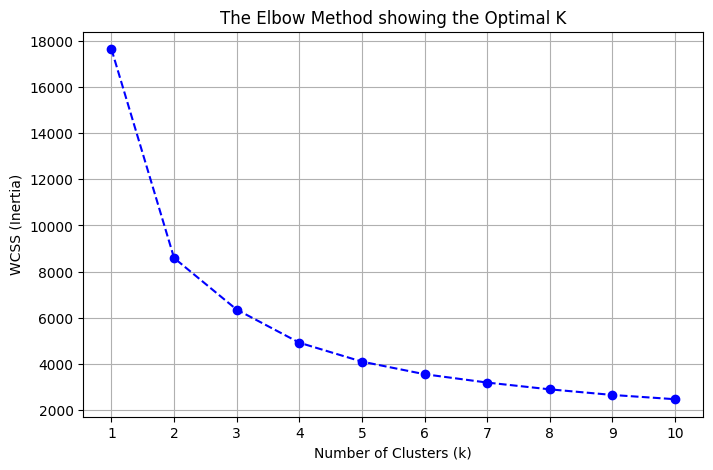

In [12]:
wcss = []
k_range = range(1, 11)

# Run K-Means for 1 to 10 clusters
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method showing the Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

<b style="color: #8A2BE2;">**Training the K-Means Model**</b>

Based on the Elbow Method, we select k=3 as the optimal number of clusters.Now train the K-Means algorithm on our scaled data and assign cluster labels to each customer in our original RFM dataset.

In [13]:
# 1. Initialize the K-Means model with 3 clusters
kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42)

# 2. Fit the model and predict cluster labels
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled_df)

# 3. View the number of customers in each cluster
print("--- Customer Count Per Cluster ---")
print(rfm['Cluster'].value_counts())

rfm.head()

--- Customer Count Per Cluster ---
Cluster
0    2455
2    2291
1    1132
Name: count, dtype: int64


,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346,326,12,77556.46,1
12347,2,8,5633.32,1
12348,75,5,2019.40,2
12349,19,4,4428.69,2
12350,310,1,334.40,0


<b style="color: #8A2BE2;">**Business Insights & Strategic Recommendations**</b>

To understand the characteristics of each cluster, we calculate the average Recency, Frequency, and Monetary values for each group. This helps us interpret and name the customer segments.

--- Average RFM Values Per Cluster ---
            Recency  Frequency      Monetary
Cluster                                     
0        370.648473   1.568228    413.096942
1         32.530035  20.068021  11504.592904
2        103.301179   4.540375   1617.667839


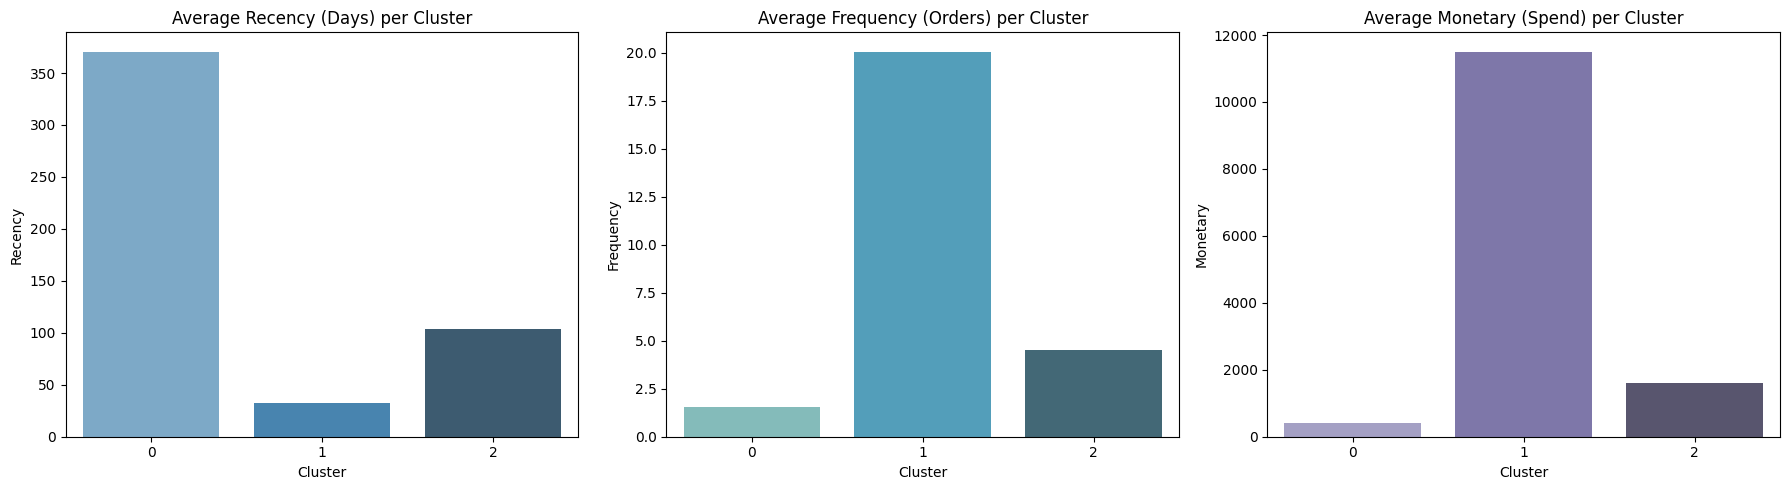

In [14]:
# 1. Calculate the mean values of RFM for each cluster
cluster_profile = rfm.groupby('Cluster').mean()
print("--- Average RFM Values Per Cluster ---")
print(cluster_profile)

# 2. Plotting the clusters to visualize the segmentation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Mean Recency
sns.barplot(x=cluster_profile.index, y=cluster_profile['Recency'], ax=axes[0], palette='Blues_d')
axes[0].set_title('Average Recency (Days) per Cluster')
axes[0].set_xlabel('Cluster')

# Plot Mean Frequency
sns.barplot(x=cluster_profile.index, y=cluster_profile['Frequency'], ax=axes[1], palette='GnBu_d')
axes[1].set_title('Average Frequency (Orders) per Cluster')
axes[1].set_xlabel('Cluster')

# Plot Mean Monetary
sns.barplot(x=cluster_profile.index, y=cluster_profile['Monetary'], ax=axes[2], palette='Purples_d')
axes[2].set_title('Average Monetary (Spend) per Cluster')
axes[2].set_xlabel('Cluster')

plt.tight_layout()
plt.show()

<b style="color: #8A2BE2;">**Business Insights & Strategic Recommendations**</b>

Based on the clustering characteristics, we can classify our customer base into three distinct behavioral segments:

---

 🟣 <b style="color: #8A2BE2;">Cluster 0 — "Churned / At-Risk Customers" (Low Value)</b>
* **Characteristics:** High Recency, very low Frequency, and very low Monetary spend.
* <b style="color: #8A2BE2;">Strategic Recommendations:</b>
    * <b style="color: #8A2BE2;">Win-Back Campaigns:</b> Launch automated email re-engagement campaigns offering special discounts.
    * <b style="color: #8A2BE2;">Feedback Surveys:</b> Send short surveys to understand why they stopped purchasing.

---

 🟣 <b style="color: #8A2BE2;">Cluster 1 — "Loyal & High-Value Champions" (VIP Customers)</b>
* **Characteristics:** Exceptionally low Recency, extremely high Frequency, and massive Monetary contribution.
* <b style="color: #8A2BE2;">Strategic Recommendations:</b>
    * <b style="color: #8A2BE2;">Premium Loyalty Program:</b> Enroll them in a VIP tier-based reward system with early access to new launches.
    * <b style="color: #8A2BE2;">Personalized Cross-Selling:</b> Recommend high-end complementary items based on past buying history.

---

 🟣 <b style="color: #8A2BE2;">Cluster 2 — "Average / Promising Customers" (Mid-Tier)</b>
* **Characteristics:** Moderate Recency, moderate Frequency, and moderate Monetary spend.
* <b style="color: #8A2BE2;">Strategic Recommendations:</b>
    * <b style="color: #8A2BE2;">Upselling via Thresholds:</b> Incentivize higher spending (e.g., "Spend $50 more to get free shipping").
    * <b style="color: #8A2BE2;">Subscription Models:</b> Offer recurring delivery plans to convert casual buying into predictable behavior.